# 02. VLM (Vision Language Model) 기초
**Day 14**

> **VLM**은 이미지와 텍스트를 함께 이해하는 모델입니다.  
> Chat Completions API에 **이미지 입력**을 추가하면 `gpt-4o` / `gpt-4o-mini`로 바로 실습할 수 있습니다.

**흐름:** Vision API 기초 → 샘플 VQA → **데이터 시각화→VLM** → **LangChain·구조화 출력** → Agent Tool → 실전 워크플로

**실습 데이터:** `samples/image_samples/` + 노트북에서 **동적 생성**하는 차트 (`generated_vlm/`)


---
## 0. 설치 & 경로

In [2]:
!pip install openai python-dotenv matplotlib pillow numpy pandas langchain langchain-openai langchain-core langchain-classic

In [3]:
import os
import base64
from pathlib import Path

from dotenv import load_dotenv
from IPython.display import Image, display
from openai import OpenAI

load_dotenv()
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
client = OpenAI(api_key=OPENAI_API_KEY)

IMAGE_SAMPLES = Path(os.getcwd()) / 'samples' / 'image_samples'
print('IMAGE_SAMPLES:', IMAGE_SAMPLES.resolve())
for p in sorted(IMAGE_SAMPLES.glob('*')):
    print(' -', p.name)

IMAGE_SAMPLES: C:\Users\finey\OneDrive\Desktop\실습폴더\14일차\samples\image_samples
 - wafer_die_map.png
 - yield_chart.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt

IMAGE_SAMPLES.mkdir(parents=True, exist_ok=True)
wafer_path = IMAGE_SAMPLES / 'wafer_die_map.png'
chart_path = IMAGE_SAMPLES / 'yield_chart.png'

if not wafer_path.exists():
  g = np.zeros((12, 12), dtype=int)
  g[2:5, 8:11] = 1; g[9, 2:6] = 1; g[4, 4] = 1; g[7, 10] = 1
  fig, ax = plt.subplots(figsize=(4, 4))
  ax.imshow(g, cmap='RdYlGn_r', vmin=0, vmax=1, interpolation='nearest')
  ax.set_title('Wafer Die Map'); fig.savefig(wafer_path, dpi=120, bbox_inches='tight')
  plt.close(fig)
  print('created', wafer_path.name)

if not chart_path.exists():
  months = ['M1','M2','M3','M4','M5','M6']
  vals = [93.2, 92.5, 91.0, 87.3, 86.8, 89.1]
  fig, ax = plt.subplots(figsize=(6, 3))
  ax.bar(months, vals, color='steelblue'); ax.set_ylabel('Yield (%)'); ax.set_ylim(80, 100)
  ax.set_title('Monthly Yield'); fig.savefig(chart_path, dpi=120, bbox_inches='tight')
  plt.close(fig)
  print('created', chart_path.name)

print('wafer:', wafer_path.exists(), '| chart:', chart_path.exists())


wafer: True | chart: True


---
## 1. VLM이란?

| 구분 | LLM (텍스트만) | VLM (Vision + Language) |
|------|----------------|-------------------------|
| 입력 | 문자열 | **이미지 + 문자열** |
| 출력 | 텍스트 | 텍스트 |
| 예시 | 요약, 번역, 코드 생성 | 이미지 설명, OCR, 차트 해석, 불량 탐지 질의 |

제조 현장 예시:
- 웨이퍼 **다이맵**에서 불량 다이 개수 세기
- 공정 **트렌드 차트**에서 최고/최저 수율 월 찾기
- 설비 **모니터 화면** 캡처에서 경고등·수치 읽기

---
## 2. Vision API 메시지 구조

텍스트만 보낼 때와 달리, `content`가 **리스트**가 됩니다.

```python
messages=[{
    'role': 'user',
    'content': [
        {'type': 'text', 'text': '이 이미지를 설명해줘'},
        {'type': 'image_url', 'image_url': {
            'url': 'data:image/png;base64,...',  # 또는 https:// URL
            'detail': 'auto',  # low | high | auto
        }},
    ],
}]
```

| `detail` | 설명 |
|----------|------|
| `low` | 저해상도 타일 — 빠르고 저렴, 전체 분위기 파악용 |
| `high` | 고해상도 — 작은 글자·숫자 읽기에 유리 |
| `auto` | 모델이 선택 (기본값) |

In [5]:
def encode_image(image_path: str | Path) -> str:
    """로컬 이미지 → base64 문자열"""
    with open(image_path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')


def ask_vision(
    image_path: str | Path,
    question: str,
    *,
    model: str = 'gpt-4o-mini',
    detail: str = 'auto',
    max_tokens: int = 500,
) -> str:
    """이미지 1장 + 질문 → 텍스트 답변"""
    path = Path(image_path)
    ext = path.suffix.lower().lstrip('.')
    mime = 'jpeg' if ext in ('jpg', 'jpeg') else ext
    b64 = encode_image(path)

    response = client.chat.completions.create(
        model=model,
        messages=[{
            'role': 'user',
            'content': [
                {'type': 'text', 'text': question},
                {'type': 'image_url', 'image_url': {
                    'url': f'data:image/{mime};base64,{b64}',
                    'detail': detail,
                }},
            ],
        }],
        max_tokens=max_tokens,
    )
    return response.choices[0].message.content

---
## Vision API 직접 호출

`ask_vision` 없이 **한 번만** API를 호출해 보세요.

**목표:** `wafer_die_map.png`에 대해 *"이 이미지를 한 문장으로 설명해줘"* 질문

**힌트:**
1. `encode_image(wafer_path)` 로 base64 문자열 생성
2. `client.chat.completions.create` 의 `messages[0]['content']`에 `text` + `image_url` 리스트 전달
3. `image_url['url']` 형식: `f'data:image/png;base64,{b64}'`

In [6]:
b64 = encode_image(wafer_path)
b64 # URL에 이미지 정보를 담기 위해 base64 방식으로 인코딩

'iVBORw0KGgoAAAANSUhEUgAAAlgAAAJYCAYAAAC+ZpjcAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjExLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlcelbwAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAILVJREFUeJzt3Qu0pXP5B/B3Lsb9Pw65THKLYujimozSRS5NrUo0aCRKy0iysoYsNIoiMhpKRlLL0hDKClEo0YVcSqnJdShCYQxmhlzG/q/nbb1n7Tmz9z6zz3nOOfuMz2etvc7M2e+7z3vf3/d5f+/vHVGr1WoFAABpRuZ9FAAAAhYAwABQwQIASCZgAQAkE7AAAJIJWAAAyQQsAIBkAhYAQDIBCwAgmYAFAJBMwAIASCZgAQAkE7AAAJIJWAAAyQQsAIBkAhYAQDIBCwAgmYAFAJBMwAIASCZgAQAkE7AAAJIJWAAAyQQsltqvfvWrYrfddivWWGONYuTIkcWIESOKAw44YJlcgj/72c/K+VtllVWGelJeVe66665iueWWK9785jcXr7zyylBPDj32h9VWW80ySfa5z32uXLZ77bVXW+/tscce5XuxbuhMAlYH+Ne//lXuKPE677zzmg538803dw+31VZbtfzM7bffvhxu4sSJKdN4/fXXF7vuumtx7bXXFk899VRRq9WKTnP77bd3L5/610orrVSss846xVve8pZi//33L84+++xi7ty5RSfqOQ+TJk3qdZxzzjlnsXG+/vWvF8PVEUccUbz88svFCSecUIb4Zi655JJil112KdZcc81ihRVWKF7/+tcXhxxySPHggw8WQ+nuu+8ujj322OId73hH8drXvrZYfvnli1VXXbXYZJNNin333be44IILiueff35Ip7ET/fvf/y4uu+yyYurUqcUOO+xQLrfYll/zmtd01LGk0euXv/zlkExj7CPx92OZxT5DB6rRETbZZJNILLXJkyc3Heakk04

In [7]:
# # ── 여기에 작성 ──
# b64 = encode_image(wafer_path)
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{
            'role': 'user',
            'content': [
                {'type': 'text', 'text': '이 이미지를 설명해줘'},
                {'type': 'image_url', 'image_url': {
                    'url': f'data:image/{'png'};base64,{b64}',
                    'detail': 'auto',
                }},
            ],
        }],
    max_tokens=500
)

print(response.choices[0].message.content)

이 이미지는 웨이퍼 다이 맵을 나타내고 있습니다. 여기서 각 사각형은 웨이퍼에서의 개별 다이를 나타내며, 색상으로 상태를 구분하고 있습니다. 

- **녹색 (0)**: 양호한 상태를 나타냅니다.
- **적색 (1)**: 실패한 상태를 나타냅니다.

전체적인 구조는 다이들이 배열된 형태를 보여주고 있으며, 실패한 다이의 위치를 시각적으로 식별할 수 있습니다.


---
## Step 1. 샘플 이미지 확인

실습용 이미지 2종:
- `wafer_die_map.png` — 12×12 다이맵 (0=양품, 1=불량)
- `yield_chart.png` — 월별 수율 막대그래프

웨이퍼 다이맵


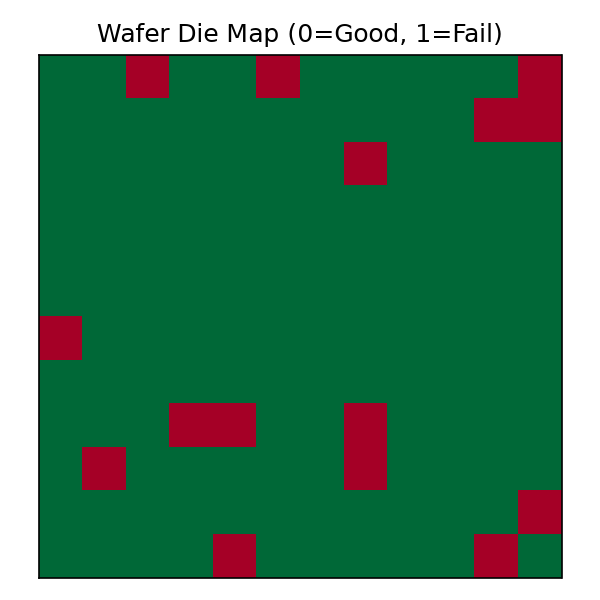

수율 차트


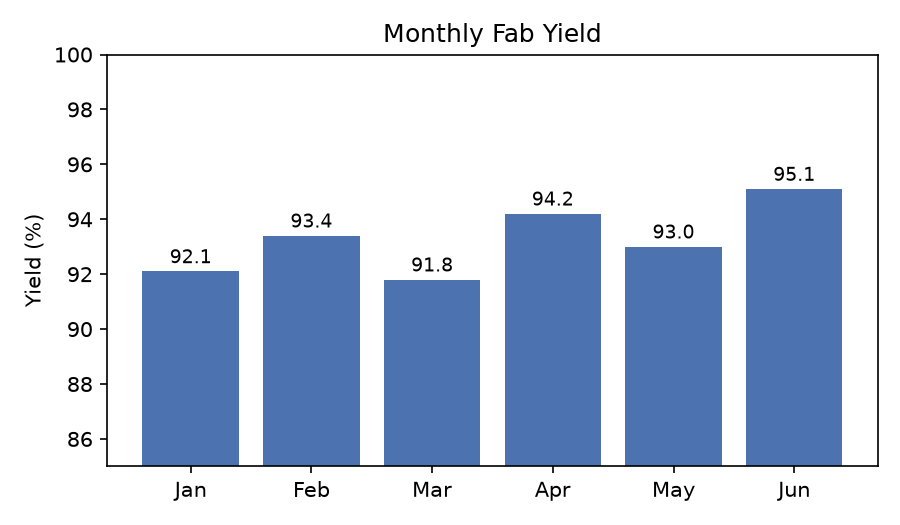

색맹 검사


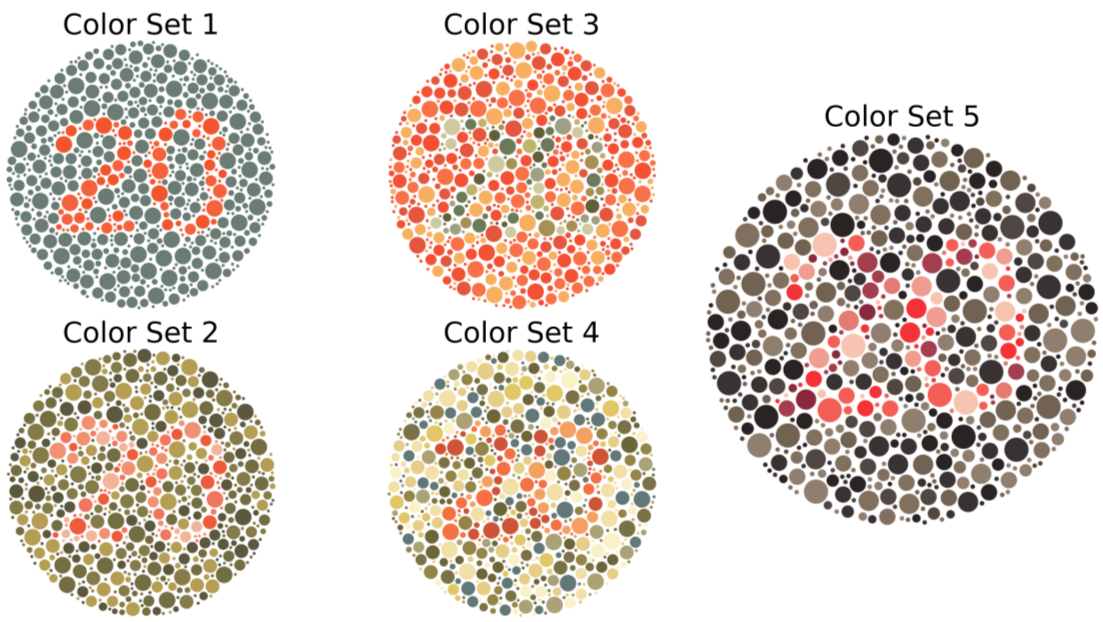

논문 이미지


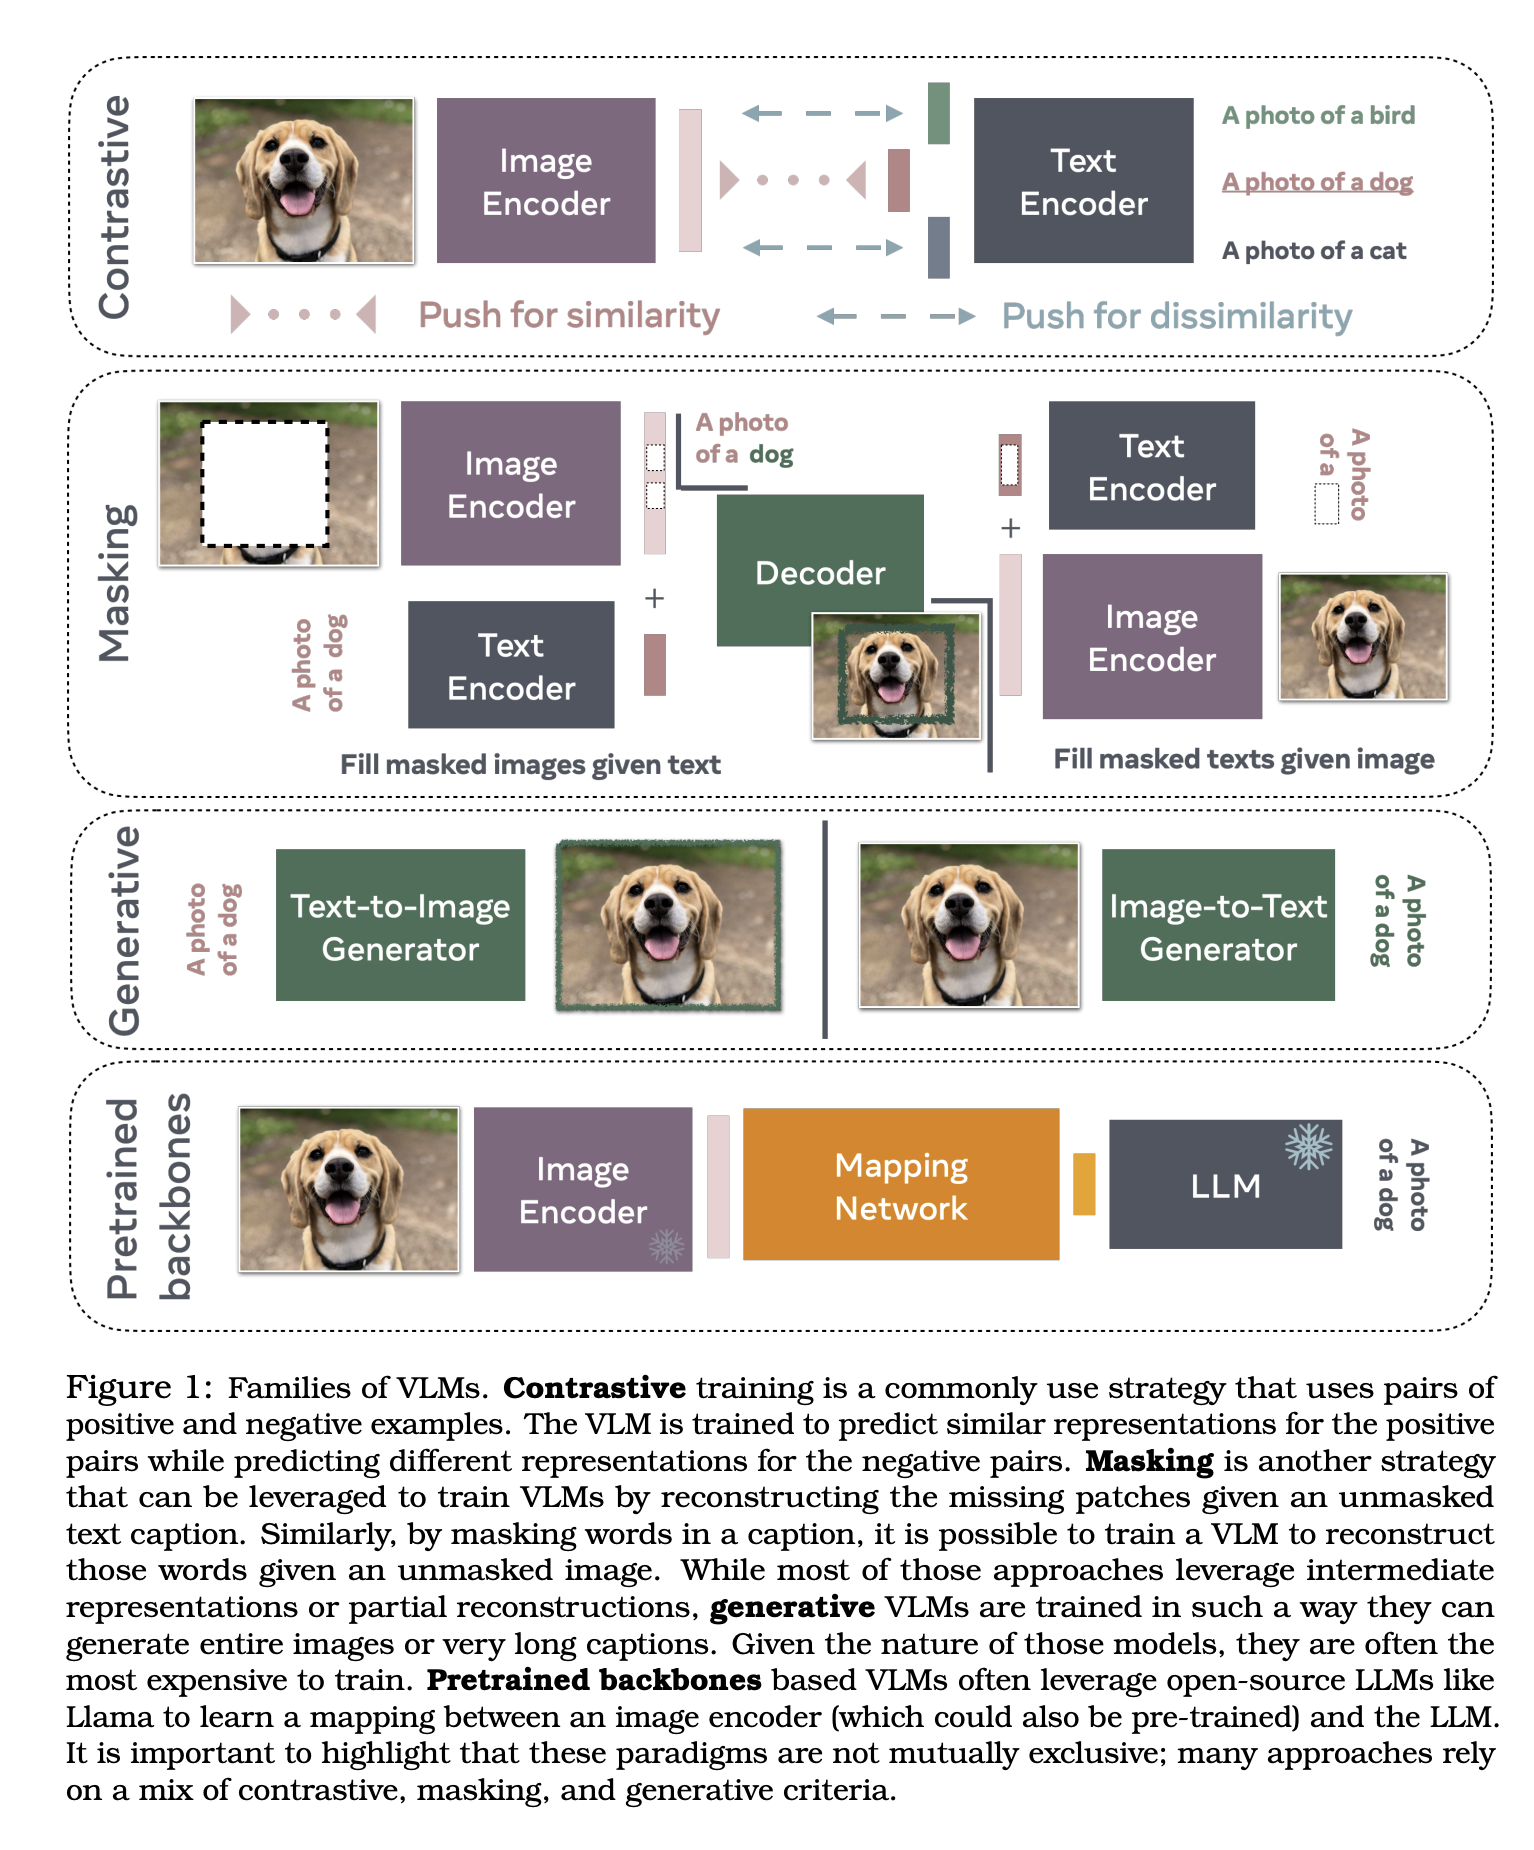

In [8]:
wafer_path = IMAGE_SAMPLES / 'wafer_die_map.png'
chart_path = IMAGE_SAMPLES / 'yield_chart.png'
cbtest_path = Path('image/colorblind test.png')
paper_path = Path('image/vlm paper.png')

print('웨이퍼 다이맵')
display(Image(filename=str(wafer_path), width=320))

print('수율 차트')
display(Image(filename=str(chart_path), width=480))

if cbtest_path.exists():
    print('색맹 검사')
    display(Image(filename=str(cbtest_path), width=480))
else:
    print('(선택) 색맹 검사 이미지 없음:', cbtest_path)

if paper_path.exists():
    print('논문 이미지')
    display(Image(filename=str(paper_path), width=480))
else:
    print('(선택) 논문 이미지 없음:', paper_path)


---
## Step 2. 이미지 설명 (Captioning)

질문 없이 **이미지가 무엇인지** 설명하게 합니다.

In [9]:
caption = ask_vision(
    wafer_path,
    '이 이미지가 무엇을 나타내는지 3문장 이내로 한국어로 설명해줘.',
)
print(caption)

이 이미지는 웨이퍼 다이 맵을 나타내며, 각 칩의 상태를 시각적으로 표현합니다. 색상으로 구분되어, 빨간색은 결함이 있는 칩(1), 초록색은 정상 칩(0)을 의미합니다. 이를 통해 전체 웨이퍼의 품질을 평가할 수 있습니다.


---
## 웨이퍼 맵에 대해 질문 작성

`wafer_die_map.png`에 대해 궁금한 질문 1개를 정해 `ask_vision`으로 호출하세요.

In [10]:
# ── 여기에 작성 ──
my_wafer_q = '패턴 분석해봐'
print(ask_vision(wafer_path, my_wafer_q))

이 와퍼 다이 맵에서 패턴을 분석해보면, '1'로 표시된 실패한 다이가 여러 군데에 흩어져 있고, 일부는 서로 가까이 위치해 있습니다. 주된 관찰 사항은 다음과 같습니다:

1. **클러스터링**: 실패한 다이들이 군집을 이루는 경향이 있으며, 특정 지역에서 여러 개의 실패가 발생하고 있습니다. 이는 시공 과정 중 특정 섹션에서 문제가 발생했음을 시사할 수 있습니다.

2. **균일성 부족**: '0'으로 표시된 양호한 다이들이 불규칙하게 분포되어 있으며, 몇몇 특정 구역에서는 상당한 수의 실패가 발생합니다. 이는 생산 과정에서의 불균일성을 나타낼 수 있습니다.

3. **무작위성**: 특정 패턴이나 일관된 구조 없이 보이는 것처럼 보이지만, 군집화된 형태는 반복적으로 나타날 수 있는 문제를 강조합니다.

이 정보를 바탕으로 문제 발생 원인을 파악하고, 공정 개선을 위한 추가 검토가 필요할 수 있습니다.


In [11]:
caption = ask_vision(
    chart_path,
    '이 이미지가 무엇을 나타내는지 3문장 이내로 한국어로 설명해줘.',
)
print(caption)

이 이미지는 월별 제조 수율(Monthly Fab Yield)을 나타내는 그래프입니다. 1월부터 6월까지의 수율 데이터를 바 그래프로 표현하고 있으며, 수율 (%)은 92.1%에서 95.1%로 증가하고 있음을 보여줍니다. 전반적으로 수율이 지속적으로 향상되고 있는 추세입니다.


In [12]:
if cbtest_path.exists():
    caption = ask_vision(
        cbtest_path,
        '이 이미지가 무엇을 나타내는지 3문장 이내로 한국어로 설명해줘.',
    )
    print(caption)
else:
    print('(선택) 색맹 검사 이미지 없음 — 셀 건너뜀')

이 이미지는 색상 세트마다 시각적으로 20이라는 숫자를 나타내는 원들이 배열되어 있습니다. 각 원은 다양한 색상의 점들로 채워져 있으며, 색상 세트에 따라 숫자의 가시성이 다를 수 있습니다. 이는 컬러 블라인드 테스트나 색각 이상을 평가하기 위한 자료일 수 있습니다.


---
## 수율 차트에 대해 질문 작성

`yield_chart.png`에 대해 궁금한 질문을 1개 정해 `ask_vision`으로 호출하세요.

In [ ]:
# ── 여기에 작성 ──
# my_question = '...'
# print(ask_vision(chart_path, my_question))

In [13]:
if paper_path.exists():
    caption = ask_vision(
        paper_path,
        '이 이미지가 무엇을 나타내는지 3문장 이내로 한국어로 설명해줘.',
    )
    print(caption)
else:
    print('(선택) 논문 이미지 없음 — 셀 건너뜀')

이 이미지는 다양한 VLM(비전-언어 모델)의 훈련 방법을 설명하고 있습니다. 상단에서는 대조 학습(Contrastive Training)과 그 원리를 보여주며, 중간 부분에는 마스킹(Masking) 기법이 설명되어 있습니다. 하단에는 생성 모델(Generative Model)을 포함한 다양한 사전 훈련(backbone) 기법이 나와 있습니다.


---
## Step 3. VQA — 웨이퍼 다이맵 질의

**Visual Question Answering**: 같은 이미지에 **구체적인 질문**을 던집니다.

웨이퍼 다이맵


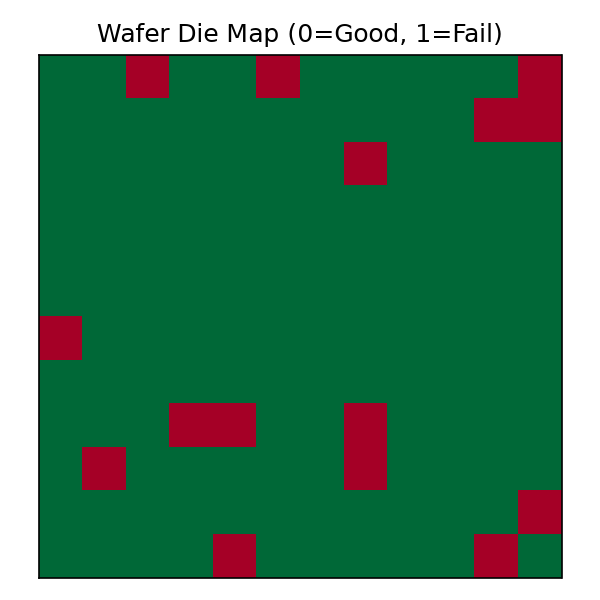

Q: 격자 크기(행×열)는 몇인가요?
A: 격자 크기(행×열)는 8×8입니다.
--------------------------------------------------
Q: 값이 1인 셀(불량 다이)은 몇 개인가요? 숫자만 답하세요.
A: 6
--------------------------------------------------
Q: 불량 다이가 모여 있는 위치가 있나요? 있다면 어느 구역인지 간단히 설명하세요.
A: 불량 다이가 모여 있는 위치는 주로 왼쪽과 오른쪽 하단 구역에 분포하고 있습니다. 중앙 구역은 상대적으로 깨끗하며, 상단과 하단의 코너에서도 몇 개의 불량 다이가 확인됩니다. 전반적으로는 분산된 형태로 보이지만, 특정 구역에서 다소 집중되어 있는 경향이 있습니다.
--------------------------------------------------


In [14]:
print('웨이퍼 다이맵')
display(Image(filename=str(wafer_path), width=320))

questions_wafer = [
    '격자 크기(행×열)는 몇인가요?',
    '값이 1인 셀(불량 다이)은 몇 개인가요? 숫자만 답하세요.',
    '불량 다이가 모여 있는 위치가 있나요? 있다면 어느 구역인지 간단히 설명하세요.',
]

for q in questions_wafer:
    print('Q:', q)
    print('A:', ask_vision(wafer_path, q, detail='auto'))
    print('-' * 50)

---
## Step 4. 차트 읽기

그래프·대시보드 캡처에서 **수치를 읽는** 대표 활용입니다.

수율 차트


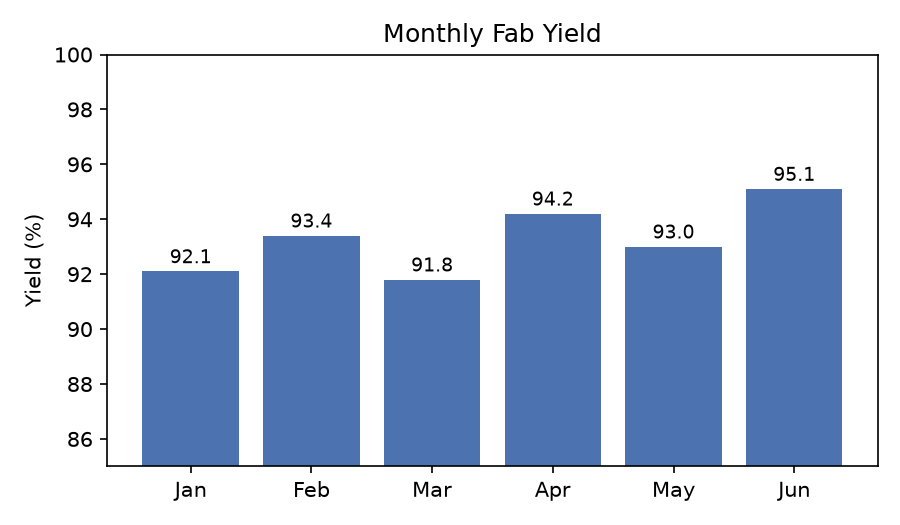

Q: 이 차트의 제목과 y축 단위를 알려줘.
A: 차트의 제목은 "Monthly Fab Yield"입니다. y축의 단위는 "Yield (%)"로, 백분율 단위로 수치를 나타냅니다.
--------------------------------------------------
Q: 수율이 가장 낮은 달과 그 값은?
A: 수율이 가장 낮은 달은 1월이고, 그 값은 92.1%입니다.
--------------------------------------------------
Q: 수율이 가장 높은 달과 그 값은?
A: 수율이 가장 높은 달은 **6월**이며, 그 값은 **95.1%**입니다.
--------------------------------------------------
Q: 6개월 평균 수율을 대략 계산해줘.
A: 6개월 동안의 수율을 계산하기 위해, 각 월의 수율을 더한 후 6으로 나누면 됩니다.

주어진 수율은 다음과 같습니다:
- 1월: 92.1%
- 2월: 93.4%
- 3월: 91.8%
- 4월: 94.2%
- 5월: 93.0%
- 6월: 95.1%

총합을 계산해보면:

\[ 
92.1 + 93.4 + 91.8 + 94.2 + 93.0 + 95.1 =  559.6 
\]

이 값을 6으로 나누면 6개월 평균 수율이 나옵니다:

\[ 
\text{평균 수율} = \frac{559.6}{6} \approx 93.27 
\]

따라서, 6개월 평균 수율은 약 93.27%입니다.
--------------------------------------------------


In [15]:
print('수율 차트')
display(Image(filename=str(chart_path), width=480))
questions_chart = [
    '이 차트의 제목과 y축 단위를 알려줘.',
    '수율이 가장 낮은 달과 그 값은?',
    '수율이 가장 높은 달과 그 값은?',
    '6개월 평균 수율을 대략 계산해줘.',
]

for q in questions_chart:
    print('Q:', q)
    print('A:', ask_vision(chart_path, q, detail='high'))
    print('-' * 50)

---
## Step 5. 데이터 시각화 → VLM — 텍스트만으로는 어려운 질문

표(CSV) 숫자만 LLM에 넣으면 **위치·형태·패턴**을 놓치기 쉽습니다.
matplotlib으로 그림을 만든 뒤 VLM에 넣으면 아래 같은 질문에 답할 수 있습니다.

| 질문 유형 | 텍스트만 | 시각화 + VLM |
|-----------|----------|-------------|
| 불량 다이가 **어느 구역에 몰렸는지** | 144개 좌표를 일일이 읽어야 함 | 히트맵에서 **클러스터**를 바로 설명 |
| 수율 **급락 구간**이 언제인지 | 숫자 나열 비교 | 막대 높이 **형태**로 인식 |
| 상관행렬에서 **강한 덩어리** | 행렬 전체 해석 부담 | 색 블록 **군집** 설명 |

아래에서는 **같은 데이터**를 텍스트 vs 이미지로 넣어 차이를 봅니다.


In [16]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GENERATED_DIR = Path('generated_vlm')
GENERATED_DIR.mkdir(exist_ok=True)


def fig_to_png_bytes(fig) -> bytes:
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return buf.read()


def ask_vision_bytes(png_bytes: bytes, question: str, *, detail: str = 'high', max_tokens: int = 500) -> str:
    b64 = base64.b64encode(png_bytes).decode('utf-8')
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{
            'role': 'user',
            'content': [
                {'type': 'text', 'text': question},
                {'type': 'image_url', 'image_url': {
                    'url': f'data:image/png;base64,{b64}',
                    'detail': detail,
                }},
            ],
        }],
        max_tokens=max_tokens,
    )
    return response.choices[0].message.content


def ask_text_only(context: str, question: str, max_tokens: int = 500) -> str:
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {'role': 'system', 'content': '주어진 데이터만 근거로 답하세요. 한국어로.'},
            {'role': 'user', 'content': f'[데이터]\n{context}\n\n[질문]\n{question}'},
        ],
        max_tokens=max_tokens,
    )
    return response.choices[0].message.content


### 5.1 웨이퍼 다이맵 — 배열 vs 히트맵

12×12 불량 배열을 **좌표 리스트**로 줄 때와 **히트맵 이미지**로 줄 때 VLM 답이 어떻게 달라지는지 비교합니다.


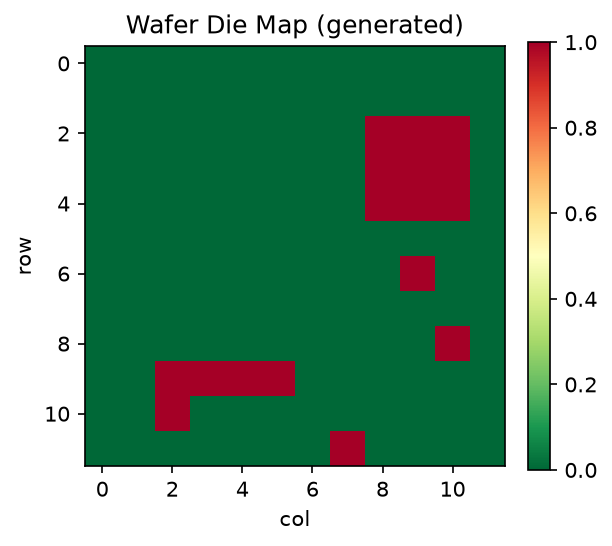

=== 텍스트만 (좌표 리스트) ===
불량 다이가 모여 있는 구역은 주로 (2, 8)에서 (4, 10)까지의 좌표입니다. 이 지역은 2행에서 4행까지의 불량 다이들이 연속적으로 위치하고 있어 밀집된 형태를 이루고 있습니다. 구체적으로 살펴보면:

- 2행: (2, 8), (2, 9), (2, 10)
- 3행: (3, 8), (3, 9), (3, 10)
- 4행: (4, 8), (4, 9), (4, 10)

이들 좌표는 각각 인접해 있어, 하나의 밀집된 불량 구역을 형성하고 있다고 볼 수 있습니다.

=== 시각화 + VLM ===
불량 다이가 모여 있는 구역을 설명하겠습니다. 

- 대체로 첫 번째 큰 그룹이 **(2, 1) ~ (4, 3)**의 범위에 위치하고 있습니다.
- 그 외에도 두 번째 작은 그룹은 **(8, 6) ~ (9, 8)**에 존재합니다.
- 추가적으로 **(7, 8)** 위치에도 또 다른 다이가 있습니다.

이런 위치들이 불량 다이가 모여 있는 곳입니다.


In [17]:
rng = np.random.default_rng(7) # 무작위로 숫자 생성
# --- 임의의 샘플 데이터 생성 ---
wafer_grid = np.zeros((12, 12), dtype=int)
wafer_grid[2:5, 8:11] = 1     
wafer_grid[9, 2:6] = 1     
for _ in range(4):
    wafer_grid[rng.integers(0, 12), rng.integers(0, 12)] = 1

defect_coords = [(int(r), int(c)) for r, c in zip(*np.where(wafer_grid == 1))]
text_context = (
    f'12x12 다이맵. 0=양품, 1=불량. '
    f'불량 좌표(row,col) 0-index: {defect_coords}'
)


# --- 샘플 기반으로 불량 map 만들기
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(wafer_grid, cmap='RdYlGn_r', vmin=0, vmax=1, interpolation='nearest')
ax.set_title('Wafer Die Map (generated)')
ax.set_xlabel('col'); ax.set_ylabel('row')
plt.colorbar(im, ax=ax, fraction=0.046)
wafer_png = fig_to_png_bytes(fig)
display(Image(data=wafer_png, width=320))


# --- 질문하기 ---
q_pattern = '불량 다이가 모여 있는 구역이 있나요? 있다면 위치를 설명하세요.'
print('=== 텍스트만 (좌표 리스트) ===')
print(ask_text_only(text_context, q_pattern))
print('\n=== 시각화 + VLM ===')
print(ask_vision_bytes(wafer_png, q_pattern))


### 5.2 수율 시계열 — 표 vs 막대 차트

월별 수율 **숫자 표**와 **막대그래프**에 같은 질문을 던집니다.  
“어느 달에 급락했는지”, “회복 추세인지”처럼 **형태** 질문은 차트가 유리한 경우가 많습니다.


C:\Users\finey\AppData\Local\Temp\ipykernel_10400\2237995204.py:12: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
C:\Users\finey\AppData\Local\Temp\ipykernel_10400\2237995204.py:12: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')


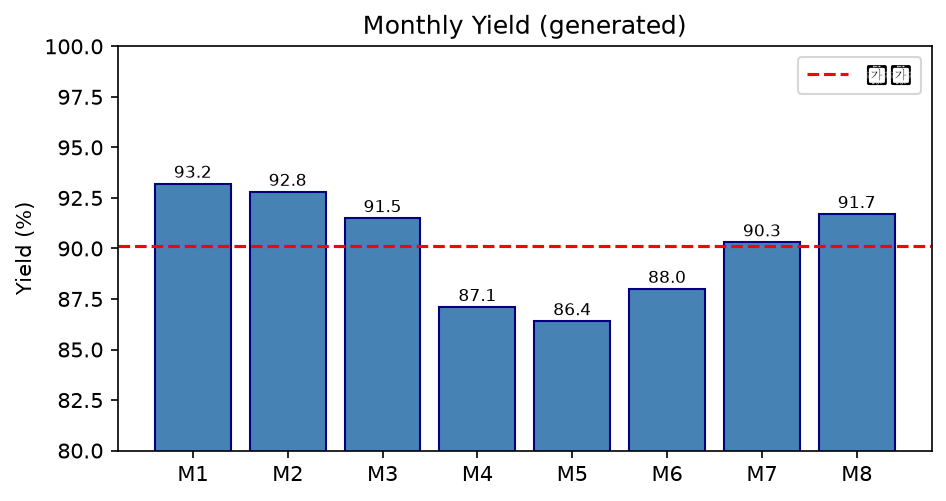

Q: 수율이 가장 낮은 달과 값은?
[텍스트] 수율이 가장 낮은 달은 M5이며, 그 값은 86.4%입니다. ...
[VLM]   수율이 가장 낮은 달은 M5이며, 값은 86.4%입니다. ...
------------------------------------------------------------
Q: 급락이 시작된 구간과 그 이후 추세를 설명해줘.
[텍스트] 급락이 시작된 구간은 M3에서 M4로 넘어가는 시점입니다. M3의 수익률이 91.5%였던 반면, M4에서는 87.1%로 급격하게 하락했습니다. 이 후 M5에서는 86.4%로 이어지며 하락세가 지속되었고, M6에서는 소폭 반등하여 88.0%를 기록하지만 여전히 M3의 수익률보다 낮은 수준입니다. 이후 M7에서 90.3%로 다시 상승이 나타났으나, M8에서는  ...
[VLM]   그래프를 보면 M3에서 M4로 넘어가는 구간에서 급락이 시작된 것을 확인할 수 있습니다. M3까지의 수치는 91.5% 이상으로 안정적인 수준이었지만, M4에서 87.1%로 급격히 떨어졌습니다.

급락 이후 추세를 살펴보면, M5와 M6에서도 여전히 80%대의 저조한 성과를 보이다가, M7에서 90.3%로 소폭 반등하고, 마지막으로 M8에서 91.7%로 다시 ...
------------------------------------------------------------


In [18]:
# 임의의 데이터 만들기
yield_df = pd.DataFrame({
    'month': ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8'],
    'yield_pct': [93.2, 92.8, 91.5, 87.1, 86.4, 88.0, 90.3, 91.7],
})
table_context = yield_df.to_string(index=False)


# --- 데이터 기반으로 막대그래프 만들기 ---
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(yield_df['month'], yield_df['yield_pct'], color='steelblue', edgecolor='navy')
ax.axhline(yield_df['yield_pct'].mean(), color='red', linestyle='--', label='평균')
ax.set_ylabel('Yield (%)'); ax.set_title('Monthly Yield (generated)')
ax.set_ylim(80, 100); ax.legend()
for b, v in zip(bars, yield_df['yield_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f'{v:.1f}', ha='center', fontsize=8)
yield_png = fig_to_png_bytes(fig)
display(Image(data=yield_png, width=520))

# --- 질문하기 ---
questions = [
    '수율이 가장 낮은 달과 값은?',
    '급락이 시작된 구간과 그 이후 추세를 설명해줘.',
]
for q in questions:
    print('Q:', q)
    print('[텍스트]', ask_text_only(table_context, q)[:200], '...')
    print('[VLM]  ', ask_vision_bytes(yield_png, q)[:200], '...')
    print('-' * 60)


### 5.3 상관 히트맵 — 다변량 관계의 ‘덩어리’ 읽기

센서 6개 상관계수 행렬을 히트맵으로 그린 뒤,  
“어떤 변수끼리 강하게 묶여 있는지”를 VLM에 묻습니다.  
숫자 36개를 나열하는 것보다 **색 블록 패턴** 설명이 자연스럽습니다.


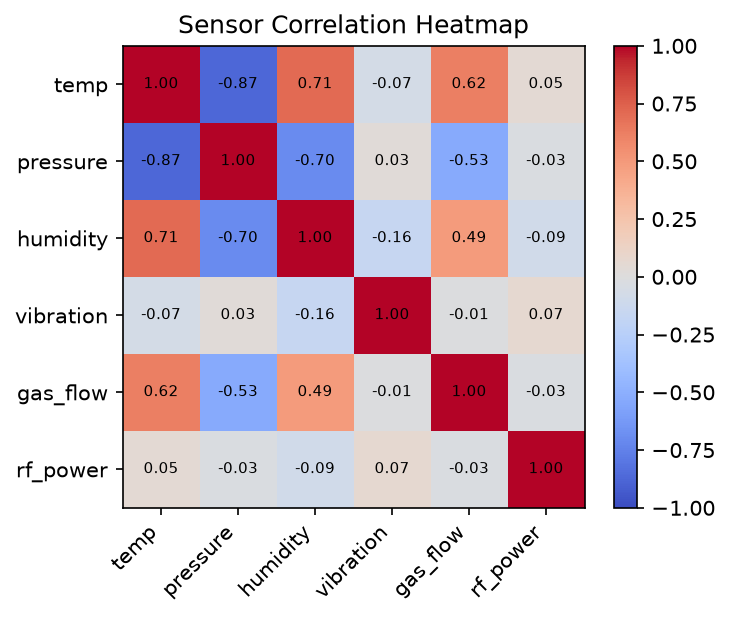

강한 양의 상관:
1. humidity - temp
2. gas_flow - humidity

강한 음의 상관:
1. temp - pressure
2. pressure - gas_flow


In [19]:
# --- 임의 데이터 만들기 ---
cols = ['temp', 'pressure', 'humidity', 'vibration', 'gas_flow', 'rf_power']
n = 200
base = rng.normal(size=n)
sensor_df = pd.DataFrame({
    'temp': base + rng.normal(0, 0.3, n),
    'pressure': -0.85 * base + rng.normal(0, 0.4, n),
    'humidity': 0.75 * base + rng.normal(0, 0.5, n),
    'vibration': rng.normal(0, 1, n),
    'gas_flow': 0.6 * base + rng.normal(0, 0.6, n),
    'rf_power': rng.normal(0, 1, n),
})
corr = sensor_df.corr().round(2)

# --- 상관계수 시각화 그래프 만들기 ---
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=45, ha='right')
ax.set_yticks(range(len(cols)), cols)
ax.set_title('Sensor Correlation Heatmap')
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
corr_png = fig_to_png_bytes(fig)
display(Image(data=corr_png, width=400))


# --- 질문하기 ---
q = (
    '히트맵에서 강한 양의 상관(빨간 덩어리)과 강한 음의 상관(파란 쌍)을 '
    '각각 2쌍 이하로 요약해줘. 변수 이름으로 답해.'
)
print(ask_vision_bytes(corr_png, q))


### 5.4 SPC 관리도 — 규칙 위반을 ‘형태’로 읽기

개별 측정값 숫자만 나열하면 **연속 7점 상승**, **2σ 밖 이탈** 같은 SPC 규칙 위반을 놓치기 쉽습니다.  
관리한계선이 그려진 관리도 이미지를 VLM에 넣으면 **시각적 규칙 위반**을 설명하게 할 수 있습니다.

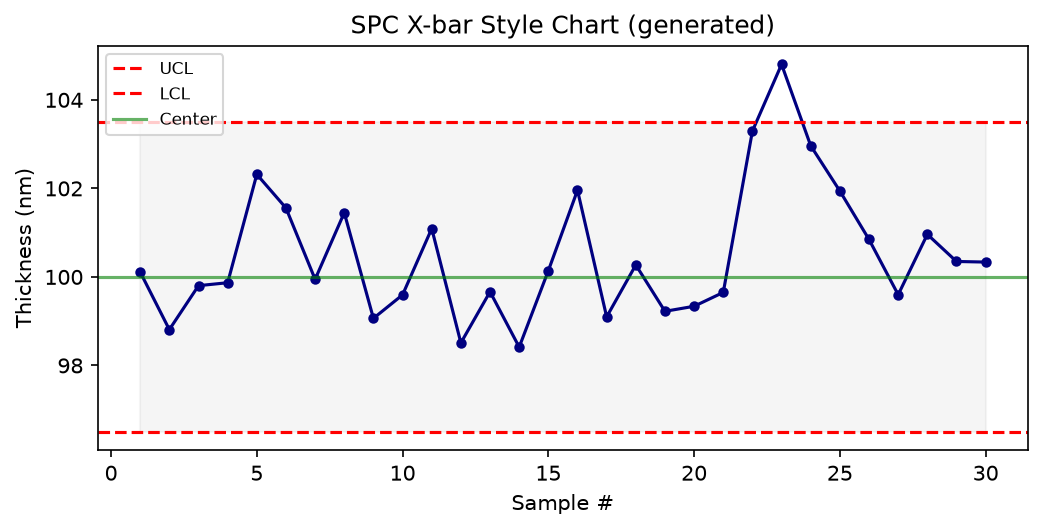

=== 텍스트 (측정값 나열) ===
주어진 데이터에서 관리 한계를 살펴보면, UCL(상한 관리 한계)인 103.5와 LCL(하한 관리 한계)인 96.5가 설정되어 있습니다.

이 데이터를 분석한 결과, 다음과 같은 이상 징후가 발견됩니다:

1. **관리 한계를 벗어난 점**: 
   - 22번째 값인 103.30은 UCL인 103.5에 매우 근접하지만, 포함되지 않습니다. 
   - 23번째 값인 104.80은 UCL(103.5)을 초과하여 관리 한계를 벗어났습니다. 이는 이상 징후로 간주될 수 있습니다.

2. **연속 상승 구간**: 
   - 22, 23, 2

=== 시각화 + VLM ===
차트를 살펴보면 다음과 같은 이상 징후가 나타납니다:

1. **관리 한계를 벗어난 점**: 24번째 샘플에서 값이 UCL(상한 지속 관리한계)인 104nm을 초과하고 있습니다. 이는 비정상적인 상태를 나타낼 수 있습니다.

2. **연속 상승 구간**: 샘플 22부터 24까지의 점들이 연속적으로 상승하고 있으며, 이는 일관된 패턴의 이상을 시사합니다.

이러한 이상 신호는 품질 관리나 공정의 문제 가능성을 암시할 수 있으므로 추가 조사가 필요할 것입니다.


In [20]:
# 임의 데이터 만들기
spc_n = 30
spc_vals = rng.normal(100, 1.2, spc_n)
spc_vals[18:25] += np.linspace(0.3, 2.8, 7)
ucl, lcl = 103.5, 96.5
center = 100.0

# --- SPC 관리도 시각화 ---
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(1, spc_n + 1), spc_vals, marker='o', markersize=4, color='navy')
ax.axhline(ucl, color='red', linestyle='--', label='UCL')
ax.axhline(lcl, color='red', linestyle='--', label='LCL')
ax.axhline(center, color='green', linestyle='-', alpha=0.6, label='Center')
ax.fill_between(range(1, spc_n + 1), lcl, ucl, alpha=0.08, color='gray')
ax.set_xlabel('Sample #'); ax.set_ylabel('Thickness (nm)')
ax.set_title('SPC X-bar Style Chart (generated)'); ax.legend(loc='upper left', fontsize=8)
spc_png = fig_to_png_bytes(fig)
display(Image(data=spc_png, width=560))

# --- 질문하기 ---
spc_text = '\n'.join(f'{i+1}: {v:.2f}' for i, v in enumerate(spc_vals))
q_spc = '관리한계를 벗어난 점이나 연속 상승 구간 같은 이상 징후가 보이나요?'
print('=== 텍스트 (측정값 나열) ===')
print(ask_text_only(f'UCL={ucl}, LCL={lcl}, center={center}\n{spc_text}', q_spc)[:300])
print('\n=== 시각화 + VLM ===')
print(ask_vision_bytes(spc_png, q_spc))

### 5.5 Confusion Matrix — 분류 성능의 ‘오답 패턴’

혼동 행렬 숫자만 주면 **어떤 불량 유형끼리 헷갈리는지** 파악이 어렵습니다.  
히트맵으로 그리면 VLM이 **대각선 밖의 진한 셀**(오분류 쌍)을 짚어 줄 수 있습니다.

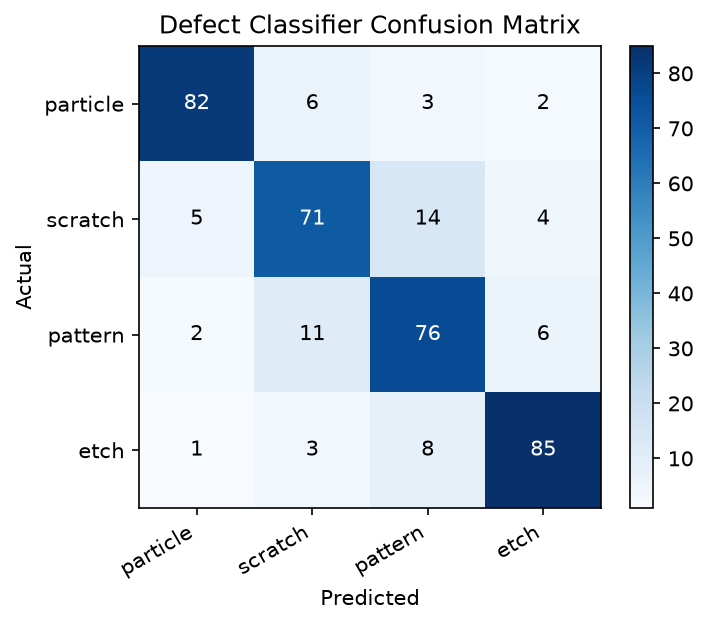

[텍스트] 1. particle → scratch 
   - 이 오분류는 실제로는 'particle'인데 'scratch'로 예측되어, 제품의 정밀도가 중요한 경우에 잘못된 품질 평가를 초래할 수 있습니다.

2. scratch → particle 
   - 실제로 'scratch'임에도 불구하고 'particle'로 예측되는 것은, 제품 검사 시 심각한 결함을 간과하게 만들어 품질 문제를 야기할 수 있습니다. ...
[VLM]   가장 심각한 오분류 쌍 두 개는 다음과 같습니다:

1. **actual: scratch → predicted: pattern**
   - 이 오분류는 실제로 스크래치인 결함이 패턴으로 잘못 분류되어, 품질 보증 과정에서 심각한 문제를 일으킬 수 있습니다.

2. **actual: pattern → predicted: scratch**
   - 패턴이 스크래치로 잘못 분류되면, 실제 결함으로 인한 문제를 간과하게 되어, 제품의 품질이 크게 저하될 위험이 있습니다.


In [21]:
# 임의의 혼동 행렬 데이터 만들기
labels = ['particle', 'scratch', 'pattern', 'etch']
cm = np.array([
    [82,  6,  3,  2],
    [ 5, 71, 14,  4],
    [ 2, 11, 76,  6],
    [ 1,  3,  8, 85],
])

# --- 혼동 행렬 시각화 ---
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels)), labels, rotation=30, ha='right')
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Defect Classifier Confusion Matrix')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > 50 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
cm_png = fig_to_png_bytes(fig)
display(Image(data=cm_png, width=400))

# --- 질문하기 ---
cm_flat = '\n'.join(f'actual={labels[i]}, pred={labels[j]}, count={cm[i,j]}' for i in range(4) for j in range(4))
q_cm = '가장 심각한 오분류 쌍 2개를 actual→predicted 형태로 짚고, 왜 문제인지 한 줄씩 설명해줘.'
print('[텍스트]', ask_text_only(cm_flat, q_cm)[:250], '...')
print('[VLM]  ', ask_vision_bytes(cm_png, q_cm))

## 나만의 VLM 활용 방법 만들고 실험하기

`samples/image_samples/` 폴더의 **웨이퍼 다이맵**·**수율 차트**를 대상으로,  
로컬 이미지 경로를 받아 VLM이 분석하는 **Fab 품질 브리핑 Tool**을 만들어 봅니다.

| 단계 | 내용 |
|------|------|
| 1 | `analyze_fab_image` — 이미지 1장 + 질문 |
| 2 | 폴더 이미지 각각 개별 분석 |
| 3 | `analyze_fab_images` — **멀티 이미지** 한 번에 종합 브리핑 |
| 4 | 질문 문장을 바꿔가며 실험 |

=== 실습 이미지 ===


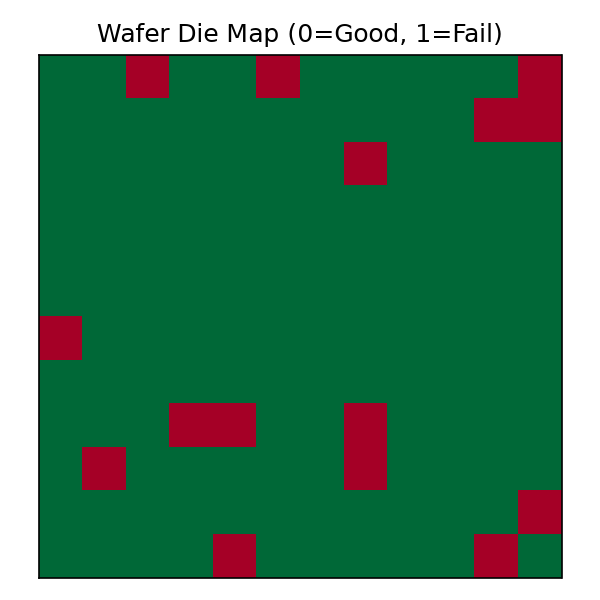

wafer_die_map.png | 8,521 bytes



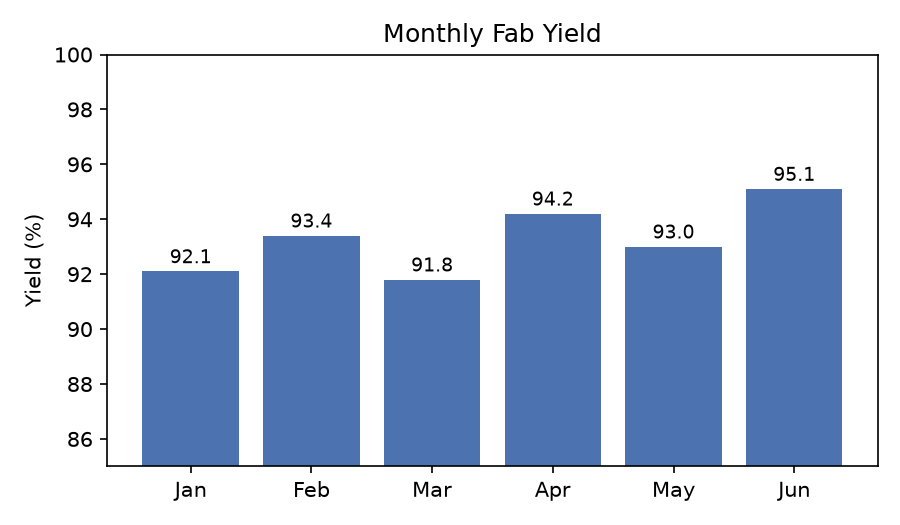

yield_chart.png | 25,461 bytes

--- [웨이퍼 다이맵] ---
빨간색(불량) 다이는 총 10개입니다. 붙어 있는 클러스터의 대략적인 위치는 다음과 같습니다:

1. **좌측 상단** (2개)
2. **중앙 왼쪽** (1개)
3. **중앙** (1개)
4. **중앙 하단** (1개)
5. **우측 하단** (2개)
6. **우측 중앙** (3개)

이러한 위치에 따라 클러스터가 형성되어 있습니다.

--- [수율 차트] ---
최고 월은 **Jun**으로 수율이 **95.1%**이고, 최저 월은 **Jan**으로 수율이 **92.1%**입니다. 

전반적 추세는 수율이 점차 증가하는 모습을 보이고 있습니다.


In [22]:
# --- 나만의 VLM 실험: 폴더 이미지 Fab 품질 브리핑 Tool ---

WAFER_IMG = IMAGE_SAMPLES / 'wafer_die_map.png'
YIELD_IMG = IMAGE_SAMPLES / 'yield_chart.png'


def analyze_fab_image(image_path: str | Path, question: str, *, detail: str = 'high') -> str:
    """로컬 이미지 경로를 받아 VLM으로 분석합니다.

    Args:
        image_path: samples/image_samples/ 등 .png/.jpg 경로
        question: 이미지에 대한 질문
    """
    path = Path(image_path)
    if not path.exists():
        return f'파일 없음: {path.resolve()}'
    return ask_vision(path, question, detail=detail, max_tokens=600)


# 1) 폴더 이미지 미리보기
print('=== 실습 이미지 ===')
for img_path in [WAFER_IMG, YIELD_IMG]:
    display(Image(filename=str(img_path), width=360))
    print(f'{img_path.name} | {img_path.stat().st_size:,} bytes\n')

# 2) 이미지별 개별 분석
wafer_q = (
    '빨간색(불량) 다이는 몇 개인가요? '
    '붙어 있는 클러스터가 있으면 대략적인 위치(상/하/좌/우)를 알려주세요.'
)
yield_q = (
    '월별 수율 중 최고·최저 월과 수치를 알려주고, '
    '전반적 추세를 한 줄로 요약해주세요.'
)

print('--- [웨이퍼 다이맵] ---')
print(analyze_fab_image(WAFER_IMG, wafer_q))

print('\n--- [수율 차트] ---')
print(analyze_fab_image(YIELD_IMG, yield_q))

In [23]:
def analyze_fab_images(image_paths: list[str | Path], question: str, *, detail: str = 'high') -> str:
    """여러 장의 로컬 이미지를 한 번에 VLM에 전달합니다."""
    content = [{'type': 'text', 'text': question}]
    for image_path in image_paths:
        path_obj = Path(image_path)
        if not path_obj.exists():
            return f'파일 없음: {path_obj.resolve()}'
        ext = path_obj.suffix.lower().lstrip('.')
        mime = 'jpeg' if ext in ('jpg', 'jpeg') else ext
        b64 = encode_image(path_obj)
        content.append({
            'type': 'image_url',
            'image_url': {
                'url': f'data:image/{mime};base64,{b64}',
                'detail': detail,
            },
        })

    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {
                'role': 'system',
                'content': '반도체 Fab 품질 분석가입니다. 이미지에 보이는 것만 근거로 한국어로 답하세요.',
            },
            {'role': 'user', 'content': content},
        ],
        max_tokens=700,
    )
    return response.choices[0].message.content


# 3) 두 이미지를 함께 넣고 종합 브리핑
joint_q = (
    '첫 번째는 웨이퍼 다이맵, 두 번째는 월별 수율 차트입니다. '
    '두 자료를 함께 보고 공정 담당자에게 보낼 4줄 품질 브리핑을 작성해주세요. '
    '(불량 분포 1줄, 수율 추세 1줄, 연관 가설 1줄, 권장 액션 1줄)'
)
print('=== 통합 Fab 브리핑 (멀티 이미지 VLM) ===')
print(analyze_fab_images([WAFER_IMG, YIELD_IMG], joint_q))

# 4) 질문을 바꿔가며 실험해 보세요
my_question = (
    '수율이 가장 낮았던 달과 웨이퍼 맵의 불량 분포를 함께 볼 때, '
    '보이는 근거만으로 어떤 가설을 세울 수 있나요?'
)
print('\n=== 나만의 질문 ===')
print(analyze_fab_images([WAFER_IMG, YIELD_IMG], my_question))

=== 통합 Fab 브리핑 (멀티 이미지 VLM) ===
불량 분포 분석 결과, 웨이퍼의 특정 영역에서 불량이 집중적으로 발생하고 있습니다. 월별 수율은 지속적으로 개선되어 6월에는 95.1%로 증가했습니다. 이를 통해 특정 영역의 불량원이 수율 향상에 영향을 미칠 수 있다는 가설이 제기됩니다. 권장 액션으로는 불량 발생 지역에 대한 추가 조사 및 공정 조정을 권장합니다.

=== 나만의 질문 ===
수율이 가장 낮았던 달은 3월로, 91.8%의 수율을 보였습니다. 웨이퍼 맵에서 불량인 다이(1로 표시된 부분)는 불규칙하게 분포되어 있는 모습을 보여줍니다.

이러한 정보를 바탕으로 다음과 같은 가설을 세울 수 있습니다:

1. **환경적 요인**: 3월의 생산 환경이나 조건이 다른 달과 달리 영향을 미쳤을 가능성이 있습니다. 예를 들어, 온도, 습도, 혹은 청정도 같은 요인이 수율 저하에 기여했을 수 있습니다.

2. **장비 문제**: 3월에 사용된 장비 혹은 공정이 다른 달의 장비와 다르거나 문제가 있었던 점은 수율 저하의 원인이 될 수 있습니다.

3. **원자재 품질**: 3월에 사용된 원자재의 품질이 낮았거나, 원자재 공급에 문제가 있었던 것일 수 있습니다. 이로 인해 불량이 발생했을 가능성도 있습니다.

4. **공정 변화**: 3월에 새로운 공정이나 방법을 시험했을 경우, 그 공정이 불완전하여 불량이 발생했을 수 있습니다.

따라서, 3월의 낮은 수율을 분석하기 위해 환경, 장비, 원자재 및 공정 관련 데이터를 추가로 조사하는 것이 중요할 것입니다.


---
## Step 6. LangChain에서 VLM 쓰기

14.1 `ChatOpenAI`와 같이 LangChain을 쓰면, `HumanMessage`의 `content`에 **텍스트 + image_url 블록**을 넣습니다.  
OpenAI SDK `client.chat.completions.create`와 **메시지 구조가 동일**합니다.

```python
HumanMessage(content=[
    {'type': 'text', 'text': '질문'},
    {'type': 'image_url', 'image_url': {'url': 'data:image/png;base64,...'}},
])
```


In [24]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

vlm_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)


def ask_vision_langchain(png_bytes: bytes, question: str, *, system: str | None = None) -> str:
    b64 = base64.b64encode(png_bytes).decode('utf-8')
    msgs = []
    if system:
        msgs.append(SystemMessage(content=system))
    msgs.append(HumanMessage(content=[
        {'type': 'text', 'text': question},
        {'type': 'image_url', 'image_url': {
            'url': f'data:image/png;base64,{b64}',
            'detail': 'high',
        }},
    ]))
    return vlm_llm.invoke(msgs).content


ans = ask_vision_langchain(
    yield_png,
    'M4~M6 구간에서 무엇이 눈에 띄나요?',
    system='반도체 공정 수율 차트 분석가. 이미지에 없는 내용은 추측하지 마세요.',
)
print(ans)


M4~M6 구간에서 눈에 띄는 점은 수율이 감소하는 경향이 있다는 것입니다. M4의 수율은 87.1%로 가장 낮고, M5는 86.4%, M6은 88.0%로 나타나며, 이 구간에서 수율이 90% 이하로 떨어진 것을 확인할 수 있습니다. 이는 M1, M2, M3의 수율과 비교했을 때 현저히 낮은 수치입니다.


### 6.1 LangChain LCEL — 시각화 → VLM 체인

함수를 Runnable로 묶으면 **데이터 → 차트 PNG → VLM 답변** 파이프라인을 재사용할 수 있습니다.


In [25]:
from langchain_core.runnables import RunnableLambda


def plot_yield_bar(df: pd.DataFrame) -> bytes:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(df['month'], df['yield_pct'], color='teal', edgecolor='black')
    ax.set_ylabel('Yield (%)'); ax.set_title('Yield Trend')
    ax.set_ylim(df['yield_pct'].min() - 3, df['yield_pct'].max() + 3)
    return fig_to_png_bytes(fig)


yield_insight_chain = (
    RunnableLambda(plot_yield_bar)
    | RunnableLambda(lambda png: ask_vision_langchain(
        png,
        '공정 담당자에게 보고할 3줄 요약을 작성해줘. 급락 원인 추정은 하지 마.',
    ))
)

print(yield_insight_chain.invoke(yield_df))


최근 수율 추세를 분석한 결과, M1에서 M3까지는 90% 이상의 수율을 유지했습니다. 그러나 M4와 M5에서 수율이 급락하여 86% 이하로 떨어졌습니다. 이후 M6, M7, M8에서 수율이 다시 회복되어 M8에서 92%에 도달했습니다.


### 6.2 LangChain — 구조화 출력 (Pydantic)

VLM 답변을 **고정 스키마**로 받으면 downstream 코드(알람, DB 저장)에 바로 연결할 수 있습니다.  
`with_structured_output`으로 차트 분석 결과를 필드 단위로 파싱합니다.

In [26]:
from pydantic import BaseModel, Field


class YieldChartInsight(BaseModel):
    lowest_month: str = Field(description='수율이 가장 낮은 달')
    lowest_value: float = Field(description='해당 달 수율(%)')
    trend_summary: str = Field(description='전반적 추세 1문장')
    alert_needed: bool = Field(description='공정 알람이 필요한 수준인지')


structured_vlm = ChatOpenAI(model='gpt-4o-mini', temperature=0).with_structured_output(YieldChartInsight)

b64_yield = base64.b64encode(yield_png).decode('utf-8')
structured_msgs = [
    SystemMessage(content='차트에 보이는 내용만 근거로 구조화 필드를 채우세요.'),
    HumanMessage(content=[
        {'type': 'text', 'text': '월별 수율 막대차트를 분석해 구조화 필드를 채워줘.'},
        {'type': 'image_url', 'image_url': {'url': f'data:image/png;base64,{b64_yield}', 'detail': 'high'}},
    ]),
]
insight = structured_vlm.invoke(structured_msgs)
print(insight)
print('알람 필요:', insight.alert_needed)

lowest_month='M4' lowest_value=87.1 trend_summary='수율이 M4에서 가장 낮았고, 이후 M5에서 소폭 증가한 후 M6, M7, M8에서 다시 상승세를 보임.' alert_needed=True
알람 필요: True


### 6.3 LangChain — 텍스트 vs Vision 병렬 비교

같은 질문을 **표 텍스트**와 **차트 이미지**에 동시에 던져 답 차이를 비교할 수 있습니다.

In [27]:
from langchain_core.runnables import RunnableParallel

compare_chain = RunnableParallel(
  text=RunnableLambda(lambda q: ask_text_only(table_context, q)),
  vision=RunnableLambda(lambda q: ask_vision_langchain(yield_png, q)),
)

cmp_q = '급락 구간 이후 수율이 회복되고 있나요? 근거를 짧게.'
cmp = compare_chain.invoke(cmp_q)
print('[text]  ', cmp['text'])
print('[vision]', cmp['vision'])

[text]   급락 구간은 M4에서 M5로 전환되며 수율이 87.1%에서 86.4%로 감소했습니다. 이후 M6에서 88.0%로 약간 회복되었고, M7에서도 90.3%로 계속 상승했습니다. 따라서, 급락 구간 이후 수율이 회복되고 있다고 볼 수 있습니다.
[vision] 네, 급락 구간 이후 수율이 회복되고 있습니다. M4에서 M6까지 수율이 낮았으나, M7과 M8에서 각각 90.3%와 91.7%로 증가하여 90%를 초과했습니다. 이는 회복세를 나타냅니다.


---
## Step 7. VLM을 Agent Tool로 — 14.1 · 15.3 연결

`@tool`에 **파일 경로**를 인자로 넘기면 Agent가 필요할 때만 아래 파이프라인을 실행합니다.

```
경로 입력 → (.csv면 matplotlib 시각화) → PNG → VLM 질의 → 텍스트 답변
```


In [28]:
from langchain_core.tools import tool
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

YIELD_CSV = GENERATED_DIR / 'yield_data.csv'
yield_df.to_csv(YIELD_CSV, index=False)

DEMO_FILES = {
    'yield_csv': str(YIELD_CSV),
    'yield_chart': str(GENERATED_DIR / 'yield_generated.png'),
    'wafer_map': str(GENERATED_DIR / 'wafer_generated.png'),
    'corr_heatmap': str(GENERATED_DIR / 'corr_heatmap.png'),
}
print('demo paths:')
for k, v in DEMO_FILES.items():
    print(f'  {k}: {v}')

demo paths:
  yield_csv: generated_vlm\yield_data.csv
  yield_chart: generated_vlm\yield_generated.png
  wafer_map: generated_vlm\wafer_generated.png
  corr_heatmap: generated_vlm\corr_heatmap.png


In [29]:
def _visualize_csv(csv_path: Path) -> Path:
    """CSV → 막대/라인 차트 PNG 저장 후 경로 반환"""
    df = pd.read_csv(csv_path)
    out_path = GENERATED_DIR / f'{csv_path.stem}_viz.png'

    fig, ax = plt.subplots(figsize=(7, 3.5))
    if df.shape[1] >= 2:
        x_col, y_col = df.columns[0], df.columns[1]
        ax.bar(df[x_col].astype(str), df[y_col], color='steelblue', edgecolor='navy')
        ax.set_ylabel(str(y_col))
        ax.set_xlabel(str(x_col))
    else:
        ax.plot(df.iloc[:, 0], marker='o', color='navy')
        ax.set_ylabel(df.columns[0])
    ax.set_title(csv_path.stem)
    png_bytes = fig_to_png_bytes(fig)
    display(Image(data=png_bytes, width=520))
    out_path.write_bytes(png_bytes)
    return out_path


@tool
def visualize_and_analyze_vlm(file_path: str, question: str) -> str:
    """CSV 또는 이미지 경로를 받아, 필요 시 시각화한 뒤 VLM으로 분석합니다.

    Args:
        file_path: .csv 데이터 파일 또는 .png/.jpg 이미지 경로
        question: 차트/이미지에 던질 질문
    """
    path = Path(file_path)
    if not path.exists():
        return f'파일 없음: {path.resolve()}'

    suffix = path.suffix.lower()
    if suffix == '.csv':
        viz_path = _visualize_csv(path)
        return ask_vision(viz_path, question, detail='high')
    if suffix in {'.png', '.jpg', '.jpeg', '.webp', '.gif'}:
        return ask_vision(path, question, detail='high')
    return f'지원하지 않는 확장자: {suffix} (csv 또는 이미지)'

In [30]:
@tool
def read_data_table(file_path: str) -> str:
    """CSV 파일 내용을 텍스트 표로 반환합니다."""
    path = Path(file_path)
    if not path.exists():
        return f'파일 없음: {path.resolve()}'
    return pd.read_csv(path).to_string(index=False)

In [31]:
agent_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.1)
vision_tools = [read_data_table, visualize_and_analyze_vlm]

vision_prompt = ChatPromptTemplate.from_messages([
    ('system', '''수율·차트 관련 질문을 처리합니다.
- 숫자 표만 필요하면 read_data_table(file_path)
- 추세·급락·패턴·시각적 해석이면 visualize_and_analyze_vlm(file_path, question)
  · CSV는 tool 내부에서 차트로 그린 뒤 VLM 분석
  · 이미지 경로는 바로 VLM 분석
사용 가능한 경로 예시:
  generated_vlm/yield_data.csv
  generated_vlm/yield_generated.png
  generated_vlm/wafer_generated.png
한국어로 답하세요.'''),
    ('human', '{input}'),
    MessagesPlaceholder('agent_scratchpad'),
])



> Entering new AgentExecutor chain...

Invoking: `visualize_and_analyze_vlm` with `{'file_path': 'generated_vlm/yield_data.csv', 'question': '이 데이터의 수율 추세는 어떤가요?'}`




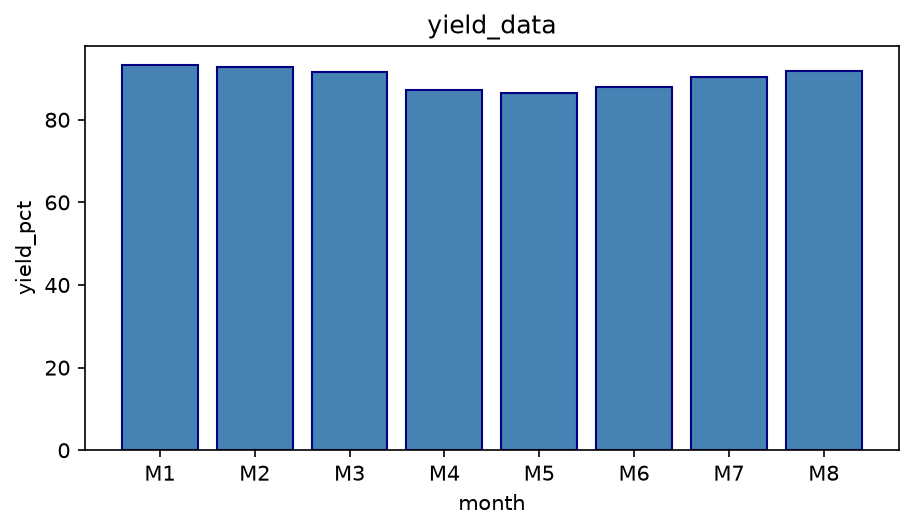

이 데이터의 수율 추세는 전반적으로 매우 안정적이고 일정합니다. 각 월의 수율은 모두 비슷한 수준으로, 약 80% 이상을 유지하고 있습니다. 따라서 특별한 변동이나 개선이 필요해 보이지 않으며, 지속적으로 높은 수준의 성과를 나타내고 있습니다.데이터의 수율 추세는 전반적으로 매우 안정적이고 일정합니다. 각 월의 수율은 모두 비슷한 수준으로, 약 80% 이상을 유지하고 있습니다. 특별한 변동이나 개선이 필요해 보이지 않으며, 지속적으로 높은 수준의 성과를 나타내고 있습니다.

> Finished chain.
데이터의 수율 추세는 전반적으로 매우 안정적이고 일정합니다. 각 월의 수율은 모두 비슷한 수준으로, 약 80% 이상을 유지하고 있습니다. 특별한 변동이나 개선이 필요해 보이지 않으며, 지속적으로 높은 수준의 성과를 나타내고 있습니다.


In [32]:
vision_agent = create_tool_calling_agent(agent_llm, vision_tools, vision_prompt)
vision_executor = AgentExecutor(agent=vision_agent, tools=vision_tools, verbose=True, max_iterations=5)

# Agent가 경로를 tool 인자로 넘기도록 질문에 파일 경로를 명시
r = vision_executor.invoke({
    'input': (
        'generated_vlm/yield_data.csv 를 시각화해서 분석해줘. '
    ),
})
print(r['output'])

---
## Step 8. 실전 워크플로 — 스캐터 이상치 + 멀티 패널 대시보드

1. **공정 파라미터 스캐터**: 정상 군집 vs 이상 점이 **시각적으로** 분리되는지 VLM에 질문  
2. **2×1 대시보드**: 수율 추이 + 불량 유형 pie를 한 장에 넣고 종합 해석 요청


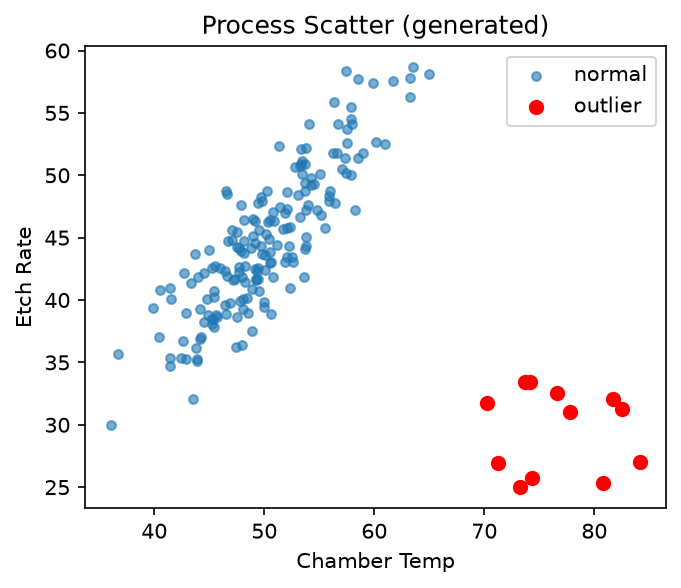

saved: generated_vlm\process_scatter.png


> Entering new AgentExecutor chain...

Invoking: `visualize_and_analyze_vlm` with `{'file_path': 'generated_vlm/process_scatter.png', 'question': '빨간 점들이 파란 점들과 비교해 공간적으로 어디에 몰려 있나요? 공정 이상 징후로 볼 만한지 설명해줘.'}`


빨간 점들(아웃라이어)은 파란 점들(노멀)과 비교했을 때, 전체 데이터 분포에서 상당히 떨어져 있는 위치에 몰려 있습니다. 주로 Chamber Temp가 70 이상인 영역에서 Etch Rate가 상대적으로 낮은 값으로 분포하고 있습니다. 이는 파란 점들과 비교하여 명확히 다르게 보이는 패턴입니다.

이러한 패턴은 공정에서 비정상적인 이상 징후로 해석될 수 있습니다. 아웃라이어가 발생하는 원인은 다양한 요인으로 인해 공정이 정상적으로 작동하지 않고 있음을 나타낼 수 있으며, 추가적인 조사 및 분석이 필요합니다. 따라서 이 데이터를 바탕으로 공정을 점검하고 조정할 필요가 있습니다.빨간 점들(아웃라이어)은 파란 점들(노멀)과 비교했을 때, 전체 데이터 분포에서 상당히 떨어져 있는 위치에 몰려 있습니다. 주로 Chamber Temp가 70 이상인 영역에서 Etch Rate가 상대적으로 낮은 값으로 분포하고 있습니다. 이는 파란 점들과 비교하여 명확히 다르게 보이는 패턴입니다.

이러한 패턴은 공정에서 비정상적인 이상 징후로 해석될 수 있습니다. 아웃라이어가 발생하는 원인은 다양한 요인으로 인해 공정이 정상적으로 작동하지 않고 있음을 나타낼 수 있으며, 추가적인 조사 및 분석이 필요합니다. 따라서 이 데이터를 바탕으로 공정을 점검하고 조정할 필요가 있습니다.

> Finished chain.
빨간 점들(아웃라이어)은 파란 점들(노멀)과 비교했을 때, 전체 데이터 분포에서 상당히 떨어져 있는 위치에 몰려 있습니다. 주로 Cha

In [ ]:
# 8.1 스캐터 — 이상치 군집
x = rng.normal(50, 5, 180)
y = 0.9 * x + rng.normal(0, 3, 180)
x_out = rng.uniform(70, 85, 12)
y_out = rng.uniform(20, 35, 12)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, y, s=18, alpha=0.6, label='normal')
ax.scatter(x_out, y_out, s=40, c='red', label='outlier')
ax.set_xlabel('Chamber Temp'); ax.set_ylabel('Etch Rate')
ax.set_title('Process Scatter (generated)'); ax.legend()
scatter_png = fig_to_png_bytes(fig)

SCATTER_IMG = GENERATED_DIR / 'process_scatter.png'
SCATTER_IMG.write_bytes(scatter_png)
display(Image(data=scatter_png, width=400))
print('saved:', SCATTER_IMG)

r = vision_executor.invoke({
    'input': (
        'generated_vlm/process_scatter.png 이미지를 분석해줘. '
        '빨간 점들이 파란 점들과 비교해 공간적으로 어디에 몰려 있나요? '
        '공정 이상 징후로 볼 만한지 설명해줘.'
    ),
})
print(r['output'])

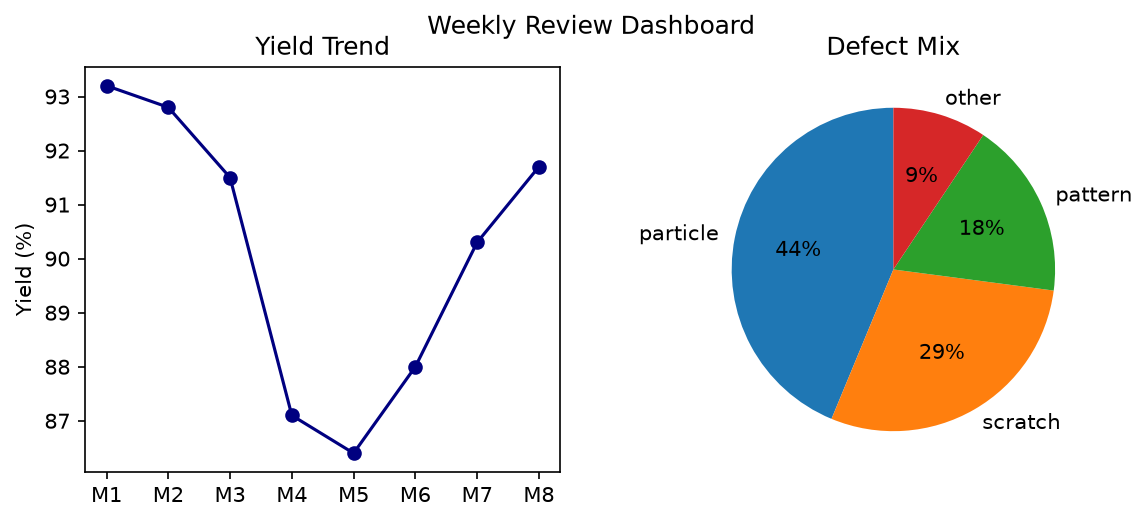

saved: generated_vlm\weekly_dashboard.png


> Entering new AgentExecutor chain...

Invoking: `visualize_and_analyze_vlm` with `{'file_path': 'generated_vlm/weekly_dashboard.png', 'question': '왼쪽 수율 추이와 오른쪽 불량 비율을 분석해줘.'}`


왼쪽의 수율 추이는 시간이 지남에 따라 변동을 보이고 있습니다. M1에서 시작하여 M2에서 급격히 감소하며 M3와 M4에서도 낮은 수치를 기록한 후, M5에서 다시 하락하여 M6에서 약간 회복세를 보입니다. M7과 M8에서는 점진적인 상승이 나타나며, 최종적으로 M8에서 91%에 도달하고 있습니다. 전체적으로 수율이 고르지 않고, 특히 M2와 M5에서 큰 하락이 있음을 알 수 있습니다.

오른쪽의 불량 비율 분석에 따르면, 불량의 주요 원인은 파르티클(44%)로 나타나 가장 큰 비중을 차지하고 있습니다. 다음으로는 스크래치(29%)와 패턴(18%)이 뒤를 잇고 있으며, 기타 원인이 9% 차지하고 있습니다. 이는 생산 과정에서 파르티클 문제를 해결하는 것이 중요하다는 것을 시사합니다. 

결론적으로, 수율 향상과 함께 주요 불량 원인인 파르티클 문제 해결이 필요합니다.주간 리뷰 미팅을 위한 4줄 브리핑:

1. 수율 추이는 M1에서 시작하여 M2에서 급격히 감소한 후, M5에서 다시 하락하여 M6에서 약간 회복세를 보였으나, M2와 M5에서의 큰 하락이 우려됩니다.
2. M7과 M8에서는 점진적인 상승이 나타나 최종적으로 M8에서 91%에 도달했습니다.
3. 불량 비율 분석 결과, 파르티클이 44%로 가장 큰 비중을 차지하며, 스크래치(29%)와 패턴(18%)이 뒤를 잇고 있습니다.
4. 따라서, 수율 향상과 함께 주요 불량 원인인 파르티클 문제 해결이 시급합니다.

> Finished chain.
주간 리뷰 미팅을 위한 4줄 브리핑:

1. 수율 추이는 M1에서 시작

In [34]:
# 8.2 멀티 패널 대시보드
defect_types = pd.Series({'particle': 42, 'scratch': 28, 'pattern': 17, 'other': 9})

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(yield_df['month'], yield_df['yield_pct'], marker='o', color='navy')
axes[0].set_title('Yield Trend'); axes[0].set_ylabel('Yield (%)')
axes[1].pie(defect_types, labels=defect_types.index, autopct='%1.0f%%', startangle=90)
axes[1].set_title('Defect Mix')
fig.suptitle('Weekly Review Dashboard', fontsize=12)
dashboard_png = fig_to_png_bytes(fig)

DASHBOARD_IMG = GENERATED_DIR / 'weekly_dashboard.png'
DASHBOARD_IMG.write_bytes(dashboard_png)
display(Image(data=dashboard_png, width=560))
print('saved:', DASHBOARD_IMG)

r = vision_executor.invoke({
    'input': (
        'generated_vlm/weekly_dashboard.png 이미지를 분석해줘. '
        '왼쪽 수율 추이와 오른쪽 불량 비율을 함께 보고, '
        '주간 리뷰 미팅용 4줄 브리핑을 작성해줘.'
    ),
})
print(r['output'])


### 8.3 설비 모니터 화면 — 수치·상태 읽기 (OCR 스타일)

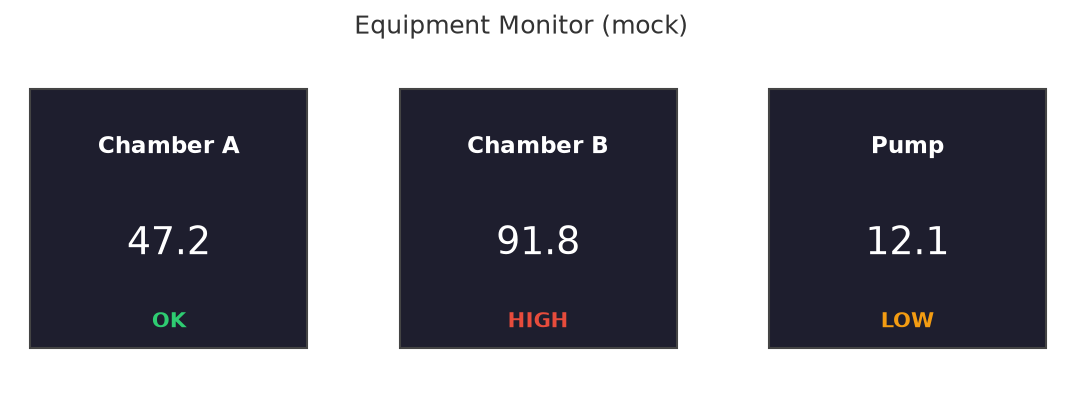

saved: generated_vlm\equipment_monitor.png


> Entering new AgentExecutor chain...

Invoking: `visualize_and_analyze_vlm` with `{'file_path': 'generated_vlm/equipment_monitor.png', 'question': '각 패널의 이름, 수치, 상태(OK/HIGH/LOW)를 표 형태로 정리하고, HIGH 또는 LOW인 항목만 조치가 필요하다고 표시해줘.'}`


| 패널 이름     | 수치  | 상태  | 조치 필요 여부    |
|---------------|-------|-------|-------------------|
| Chamber A     | 47.2  | OK    | -                 |
| Chamber B     | 91.8  | HIGH  | 조치 필요         |
| Pump          | 12.1  | LOW   | 조치 필요         |다음은 이미지에서 분석한 결과입니다:

| 패널 이름     | 수치  | 상태  | 조치 필요 여부    |
|---------------|-------|-------|-------------------|
| Chamber A     | 47.2  | OK    | -                 |
| Chamber B     | 91.8  | HIGH  | 조치 필요         |
| Pump          | 12.1  | LOW   | 조치 필요         |

조치가 필요한 항목은 Chamber B와 Pump입니다.

> Finished chain.
다음은 이미지에서 분석한 결과입니다:

| 패널 이름     | 수치  | 상태  | 조치 필요 여부    |
|---------------|-------|-------|-------------------|
| Chamber A     | 47.2  | OK    | -     

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(9, 2.8))
metrics = [('Chamber A', 47.2, 'OK'), ('Chamber B', 91.8, 'HIGH'), ('Pump', 12.1, 'LOW')]
colors = {'OK': '#2ecc71', 'HIGH': '#e74c3c', 'LOW': '#f39c12'}
for ax, (name, val, status) in zip(axes, metrics):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.1), 0.9, 0.8, fill=True, facecolor='#1e1e2e', edgecolor='#444'))
    ax.text(0.5, 0.72, name, ha='center', va='center', color='white', fontsize=11, weight='bold')
    ax.text(0.5, 0.42, f'{val:.1f}', ha='center', va='center', color='white', fontsize=18)
    ax.text(0.5, 0.18, status, ha='center', va='center', color=colors[status], fontsize=10, weight='bold')
fig.suptitle('Equipment Monitor (mock)', color='#333', fontsize=12)
monitor_png = fig_to_png_bytes(fig)

MONITOR_IMG = GENERATED_DIR / 'equipment_monitor.png'
MONITOR_IMG.write_bytes(monitor_png)
display(Image(data=monitor_png, width=560))
print('saved:', MONITOR_IMG)

r = vision_executor.invoke({
    'input': (
        'generated_vlm/equipment_monitor.png 이미지를 분석해줘. '
        '각 패널의 이름, 수치, 상태(OK/HIGH/LOW)를 표 형태로 정리하고, '
        'HIGH 또는 LOW인 항목만 조치가 필요하다고 표시해줘.'
    ),
})
print(r['output'])

### 8.4 Before/After — 공정 개선 효과를 한 장에

개선 전·후 차트를 나란히 배치하면 VLM이 **시각적 개선 폭**을 요약하는 데 유리합니다.

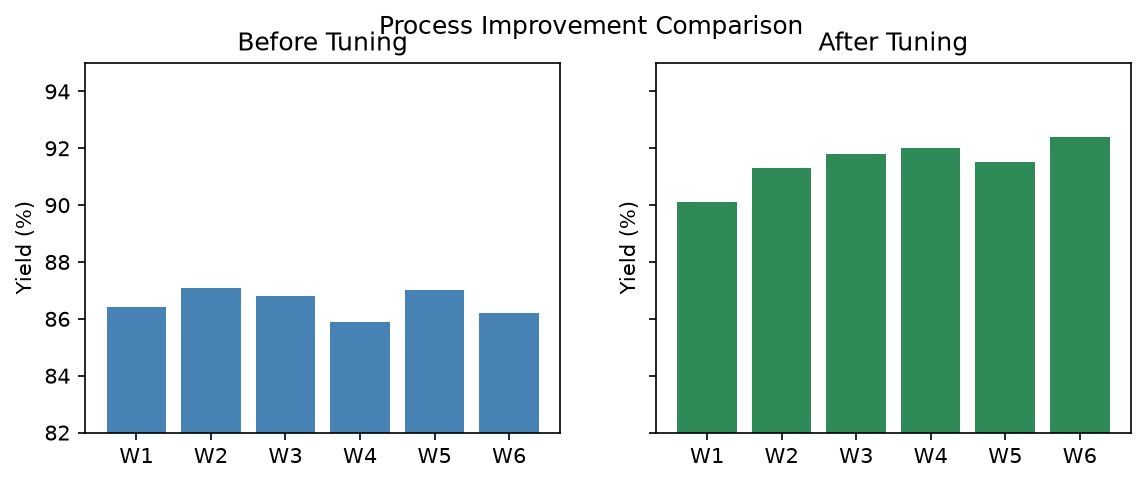

saved: generated_vlm\before_after_yield.png


> Entering new AgentExecutor chain...

Invoking: `visualize_and_analyze_vlm` with `{'file_path': 'generated_vlm/before_after_yield.png', 'question': '왼쪽(Before)과 오른쪽(After)을 비교해 수율 개선 폭과 안정성 변화를 3문장으로 요약해줘.'}`


왼쪽(Before) 그래프에서 수율은 82%에서 88% 사이로 다양하게 분포하며 비교적 낮은 안정성을 보입니다. 오른쪽(After) 그래프에서는 수율이 90% 이상으로 향상되어 일관성을 나타내고 있습니다. 따라서, 프로세스 조정을 통해 수율 개선과 안정성 향상이 동시에 이루어진 것을 확인할 수 있습니다.왼쪽(Before) 그래프에서 수율은 82%에서 88% 사이로 다양하게 분포하며 비교적 낮은 안정성을 보입니다. 오른쪽(After) 그래프에서는 수율이 90% 이상으로 향상되어 일관성을 나타내고 있습니다. 따라서, 프로세스 조정을 통해 수율 개선과 안정성 향상이 동시에 이루어진 것을 확인할 수 있습니다.

> Finished chain.
왼쪽(Before) 그래프에서 수율은 82%에서 88% 사이로 다양하게 분포하며 비교적 낮은 안정성을 보입니다. 오른쪽(After) 그래프에서는 수율이 90% 이상으로 향상되어 일관성을 나타내고 있습니다. 따라서, 프로세스 조정을 통해 수율 개선과 안정성 향상이 동시에 이루어진 것을 확인할 수 있습니다.


In [36]:
before = [86.4, 87.1, 86.8, 85.9, 87.0, 86.2]
after = [90.1, 91.3, 91.8, 92.0, 91.5, 92.4]
weeks = [f'W{i}' for i in range(1, 7)]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, data, title in zip(axes, [before, after], ['Before Tuning', 'After Tuning']):
    ax.bar(weeks, data, color='steelblue' if 'Before' in title else 'seagreen')
    ax.set_title(title); ax.set_ylabel('Yield (%)'); ax.set_ylim(82, 95)
fig.suptitle('Process Improvement Comparison')
ba_png = fig_to_png_bytes(fig)

BA_IMG = GENERATED_DIR / 'before_after_yield.png'
BA_IMG.write_bytes(ba_png)
display(Image(data=ba_png, width=560))
print('saved:', BA_IMG)

r = vision_executor.invoke({
    'input': (
        'generated_vlm/before_after_yield.png 이미지를 분석해줘. '
        '왼쪽(Before)과 오른쪽(After)을 비교해 수율 개선 폭과 안정성 변화를 3문장으로 요약해줘.'
    ),
})
print(r['output'])

---
## 나만의 차트 → VLM

pandas DataFrame이나 numpy 배열로 **본인 데이터**를 시각화한 뒤,  
텍스트만으로는 답하기 어려운 질문 1개를 VLM에 던져 보세요.

**아이디어:** 라인+이상 구간, boxplot, 공정 SPC 관리도, confusion matrix 히트맵 …


In [ ]:
# ── day2-1_data.csv → 시각화 → VLM ──
DATA_PATH = Path('data/day2-1_data.csv')
my_df = pd.read_csv(DATA_PATH)
my_df.columns = my_df.columns.str.strip()

print('shape:', my_df.shape)
print(my_df[['Water', 'Age', 'Concrete_compressive_strength']].describe().round(2))

# 2패널: (1) 물 함량 vs 압축강도  (2) 양생 일수별 강도 분포
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sc = axes[0].scatter(
    my_df['Water'],
    my_df['Concrete_compressive_strength'],
    c=my_df['Age'],
    cmap='viridis',
    alpha=0.5,
    s=20,
)
axes[0].set_xlabel('Water (kg)')
axes[0].set_ylabel('Compressive Strength (MPa)')
axes[0].set_title('Water vs Strength (color = Age)')
fig.colorbar(sc, ax=axes[0], fraction=0.046, label='Age (days)')

common_ages = [28, 90, 180, 365]
plot_df = my_df[my_df['Age'].isin(common_ages)]
strength_by_age = [
    plot_df.loc[plot_df['Age'] == age, 'Concrete_compressive_strength']
    for age in common_ages
]
axes[1].boxplot(strength_by_age, tick_labels=[str(a) for a in common_ages])
axes[1].set_xlabel('Age (days)')
axes[1].set_ylabel('Compressive Strength (MPa)')
axes[1].set_title('Strength by Curing Age')

fig.suptitle('Concrete Compressive Strength (day2-1_data)', fontsize=12)
fig.tight_layout()

my_png = fig_to_png_bytes(fig)
display(Image(data=my_png, width=560))

# 텍스트만 vs VLM 비교
table_ctx = my_df[['Water', 'Age', 'Concrete_compressive_strength']].describe().round(2).to_string()
q = (
    '왼쪽 산점도와 오른쪽 박스플롯을 보고 답하세요. '
    '1) 물(Water) 함량과 압축 강도의 관계, '
    '2) 양생 일수(Age)가 길어질수록 강도 분포가 어떻게 변하는지, '
    '3) 배합 설계 시 주의할 점 1가지를 한국어로 요약해주세요.'
)
print('\n=== 텍스트만 (describe 통계) ===')
print(ask_text_only(table_ctx, q)[:350], '...\n')
print('=== 시각화 + VLM ===')
print(ask_vision_bytes(my_png, q, detail='high', max_tokens=700))


---
## LangChain 구조화 출력 필드 설계

`YieldChartInsight`처럼 **본인 도메인**에 맞는 Pydantic 모델을 정의하고,  
5.4 SPC 차트 또는 5.5 혼동행렬 이미지에 대해 구조화 출력을 받아 보세요.

**힌트:** `Field(description=...)`에 VLM이 채울 항목을 명확히 적습니다.

In [ ]:
# ── 여기에 작성 ──
# class SpcAlert(BaseModel):
#     rule_violations: list[str] = Field(description='관측된 SPC 규칙 위반 목록')
#     severity: ...
#
#
# structured = ChatOpenAI(model='gpt-4o-mini', temperature=0).with_structured_output(SpcAlert)
# ... HumanMessage with spc_png ...
# print(structured.invoke(msgs))

---
## Step 9. `detail` 옵션 비교

같은 질문이라도 `detail`에 따라 토큰 사용량·정확도가 달라집니다.  
작은 숫자·글자를 읽을 때는 `high`를 쓰는 편이 안전합니다.

---
## `detail` 옵션 비교

같은 이미지·같은 질문으로 `detail='low'` 와 `detail='high'` 결과를 비교해 보세요.

**관찰 포인트:** 응답 길이, 구체성, 토큰 사용량(대략) 차이

In [ ]:
# ── 여기에 작성 ──
# question = '웨이퍼 맵에서 불량 다이 패턴을 설명해줘'
# for detail in ('low', 'high'):
#     print(f'=== detail={detail} ===')
#     print(ask_vision(wafer_path, question, detail=detail))
#     print()

In [ ]:
demo_path = paper_path if paper_path.exists() else wafer_path
demo_label = '논문 이미지' if paper_path.exists() else '웨이퍼 다이맵 (대체)'
print(demo_label)
display(Image(filename=str(demo_path), width=480))

if paper_path.exists():
    q = '논문 이미지의 텍스트 내용 중 Pretrained Backbones 관련 문장을 텍스트로 옮겨 줘'
else:
    q = '불량 다이 패턴을 설명하고, detail 옵션에 따라 답이 달라지는지 관찰해 보세요.'

for detail in ['low', 'high']:
    ans = ask_vision(demo_path, q, detail=detail, max_tokens=120)
    print(f'detail={detail:4s} → {ans[:200]}')
    print()

---
## Step 10. 시스템 프롬프트 + 구조화 출력

Day 3 프롬프트 엔지니어링과 같이 **역할·출력 형식**을 지정할 수 있습니다.

In [ ]:
def inspect_wafer(image_path: str | Path) -> str:
    path = Path(image_path)
    b64 = encode_image(path)

    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {
                'role': 'system',
                'content': (
                    '당신은 반도체 수율 분석 보조 AI입니다. '
                    '이미지에 없는 내용은 추측하지 마세요. 한국어로 답하세요.'
                ),
            },
            {
                'role': 'user',
                'content': [
                    {'type': 'text', 'text': (
                        '다이맵을 분석하고 아래 형식으로만 답하세요.\n'
                        '- 격자 크기:\n'
                        '- 양품(0) 개수:\n'
                        '- 불량(1) 개수:\n'
                        '- 불량률(%):'
                    )},
                    {'type': 'image_url', 'image_url': {
                        'url': f'data:image/png;base64,{b64}',
                        'detail': 'high',
                    }},
                ],
            },
        ],
        max_tokens=300,
    )
    return response.choices[0].message.content


print(inspect_wafer(wafer_path))

---
## Step 11. 정리 — URL 이미지도 가능

로컬 파일 대신 **공개 URL**을 넣을 수도 있습니다. (인터넷 연결 필요)

| 단계 | 내용 |
|------|------|
| 1~4 | Vision API · 샘플 VQA |
| 5 | 시각화→VLM (SPC·혼동행렬·판단 기준 포함) |
| 6 | LangChain 멀티모달 · LCEL · Pydantic 구조화 |
| 7 | Agent Tool로 Vision 위임 |
| 8 | 스캐터·대시보드·모니터·Before/After |
| 9~10 | detail · 구조화 출력 |


In [ ]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{
        'role': 'user',
        'content': [
            {'type': 'text', 'text': '이 이미지에 무엇이 보이나요? 한 문장으로.'},
            {'type': 'image_url', 'image_url': {
                'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/1/1a/Faker_2020_interview.jpg/500px-Faker_2020_interview.jpg',
            }},
        ],
    }],
    max_tokens=100,
)
print(response.choices[0].message.content)